In [1]:
import sys
from argparse import Namespace
from pathlib import Path
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import torch
import tifffile

sys.path.insert(0, str(Path('/root/project')))
from scripts._3dgs._3dgs import AABB, GaussianCloud, VolumeDataset, render_splatted_mips

img_blocks_dirs = glob('/root/project/data/fafb/blocks/image_*.tif')
seg_blocks_dirs = glob('/root/project/data/fafb/blocks/segment_*.tif')

plane_blocks = {
    'xy': [
        (0, 0, 0),
        (0, 0, 1),
        (0, 1, 0),
        (0, 1, 1),
    ],
    'zy': [
        (0, 0, 0),
        (0, 1, 0),
        (1, 0, 0),
        (1, 1, 0),
    ],
    'zx': [
        (0, 0, 0),
        (0, 0, 1),
        (1, 0, 0),
        (1, 0, 1),
    ],
}

In [2]:
# Stitch blocks to create 2x2x2 volume based on the plane blocks 
def stitch_blocks(plane: str, blocks: list):
    assert plane in plane_blocks, f"Invalid plane: {plane}. Must be one of {list(plane_blocks.keys())}"
    assert len(blocks) == 4, f"Expected 4 blocks for stitching, got {len(blocks)}"

    # Create an empty volume to hold the stitched result
    stitched_volume = np.zeros((2 * blocks[0].shape[0], 2 * blocks[0].shape[1], 2 * blocks[0].shape[2]), dtype=blocks[0].dtype)

    for idx, (x, y, z) in enumerate(plane_blocks[plane]):
        stitched_volume[x * blocks[idx].shape[0]:(x + 1) * blocks[idx].shape[0],
                        y * blocks[idx].shape[1]:(y + 1) * blocks[idx].shape[1],
                        z * blocks[idx].shape[2]:(z + 1) * blocks[idx].shape[2]] = blocks[idx]

    return stitched_volume

img_blocks_dirs[:-1]

['/root/project/data/fafb/blocks/image_z0_y0_x0.tif',
 '/root/project/data/fafb/blocks/image_z0_y0_x1.tif',
 '/root/project/data/fafb/blocks/image_z0_y0_x2.tif',
 '/root/project/data/fafb/blocks/image_z0_y0_x3.tif',
 '/root/project/data/fafb/blocks/image_z0_y0_x4.tif',
 '/root/project/data/fafb/blocks/image_z0_y0_x5.tif',
 '/root/project/data/fafb/blocks/image_z0_y0_x6.tif',
 '/root/project/data/fafb/blocks/image_z0_y0_x7.tif',
 '/root/project/data/fafb/blocks/image_z0_y0_x8.tif',
 '/root/project/data/fafb/blocks/image_z0_y0_x9.tif',
 '/root/project/data/fafb/blocks/image_z0_y0_x10.tif',
 '/root/project/data/fafb/blocks/image_z0_y0_x11.tif',
 '/root/project/data/fafb/blocks/image_z0_y0_x12.tif',
 '/root/project/data/fafb/blocks/image_z0_y0_x13.tif',
 '/root/project/data/fafb/blocks/image_z0_y0_x14.tif',
 '/root/project/data/fafb/blocks/image_z0_y0_x15.tif',
 '/root/project/data/fafb/blocks/image_z0_y0_x16.tif',
 '/root/project/data/fafb/blocks/image_z0_y0_x17.tif',
 '/root/project/data

In [3]:
x_lst = glob(f'/root/project/data/fafb/blocks/image_z{0}_y{0}_x*.tif')
y_lst = glob(f'/root/project/data/fafb/blocks/image_z{0}_y*_x{0}.tif')
z_lst = glob(f'/root/project/data/fafb/blocks/image_z*_y{0}_x{0}.tif')

In [4]:
import tifffile as tiff
plane_blocks = {
    'xy': [
        (0, 0, 0),
        (0, 0, 1),
        (0, 1, 0),
        (0, 1, 1),
    ],
    'zy': [
        (0, 0, 0),
        (0, 1, 0),
        (1, 0, 0),
        (1, 1, 0),
    ],
    'zx': [
        (0, 0, 0),
        (0, 0, 1),
        (1, 0, 0),
        (1, 0, 1),
    ],
}
# concatenate the blocks along the specified plane (xy is handled separately below,
# since it needs the z=0 and z=1 slabs stitched then joined along z)
for plane in ('zy', 'zx'):
    blocks = plane_blocks[plane]
    paths = [f'/root/project/data/fafb/blocks/image_z{z}_y{y}_x{x}.tif' for (z, y, x) in blocks]
    imgs = [tiff.imread(p) for p in paths]
    stitched_volume = stitch_blocks(plane, imgs)
    plt.figure(figsize=(10, 10))
    plt.imshow(stitched_volume[3], cmap='gray')
    plt.title(f'Stitched Volume along {plane} plane')
    plt.show()

/tmp/ipykernel_151321/3785043196.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [5]:
# xy plane: stitch the 2x2 tile at z=0, stitch the 2x2 tile at z=1, then join along z
xy_z0_coords = [(0, 0, 0), (0, 0, 1), (0, 1, 0), (0, 1, 1)]
xy_z1_coords = [(1, 0, 0), (1, 0, 1), (1, 1, 0), (1, 1, 1)]

def load_imgs(coords):
    paths = [f'/root/project/data/fafb/blocks/image_z{z}_y{y}_x{x}.tif' for (z, y, x) in coords]
    return [tiff.imread(p) for p in paths]

block_z = load_imgs(xy_z0_coords)[0].shape[0]

xy_z0_tile = stitch_blocks('xy', load_imgs(xy_z0_coords))[:block_z]
xy_z1_tile = stitch_blocks('xy', load_imgs(xy_z1_coords))[:block_z]

xy_full = np.concatenate([xy_z0_tile, xy_z1_tile], axis=0)

plt.figure(figsize=(10, 10))
plt.imshow(xy_full[90], cmap='gray')
plt.title('Stitched xy volume, z=0 slab')
plt.show()

/tmp/ipykernel_151321/1664772187.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [6]:
# xy plane: stitch the 2x2 tile at z=0, stitch the 2x2 tile at z=1, then join along z
xy_z0_coords = [(0, 0, 0), (0, 0, 1), (0, 1, 0), (0, 1, 1)]
xy_z1_coords = [(1, 0, 0), (1, 0, 1), (1, 1, 0), (1, 1, 1)]

def load_imgs(coords):
    paths = [f'/root/project/data/fafb/blocks/segment_z{z}_y{y}_x{x}.tif' for (z, y, x) in coords]
    return [tiff.imread(p) for p in paths]

block_z = load_imgs(xy_z0_coords)[0].shape[0]

xy_z0_tile = stitch_blocks('xy', load_imgs(xy_z0_coords))[:block_z]
xy_z1_tile = stitch_blocks('xy', load_imgs(xy_z1_coords))[:block_z]

xy_full = np.concatenate([xy_z0_tile, xy_z1_tile], axis=0)

plt.figure(figsize=(10, 10))
plt.imshow(xy_full[90], cmap='gray')
plt.title('Stitched xy volume, z=0 slab')
plt.show()
xy_full[90]

/tmp/ipykernel_151321/4083047233.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


array([[31598387560, 31598387560, 31598387560, ...,  3823514374,
         3823514374,  3823514374],
       [31598387560, 31598387560, 31598387560, ...,  3823514374,
         3823514374,  3823514374],
       [31598387560, 31598387560, 31598387560, ...,  3823514374,
         3823514374,  3823514374],
       ...,
       [          0,           0,           0, ...,  3823516178,
         3823516178,  3823516178],
       [          0,           0,           0, ...,  3823516178,
         3823516178,  3823516178],
       [          0,           0,           0, ...,  3823516178,
         3823516178,  3823516178]], shape=(128, 128), dtype=uint64)

In [7]:
# find the ids and the number of unique ids in the stitched volume
unique_ids = np.unique(xy_full)
num_unique_ids = len(unique_ids)
# number of captured voxels with each unique id
voxel_counts = dict({id : np.sum(xy_full == id) for id in unique_ids})
# sort by values
voxel_counts = dict(sorted(voxel_counts.items(), key=lambda item: item[1], reverse=True))
voxel_counts
# select the voxels with the ids withh highest number of voxels
top_ids = list(voxel_counts.keys())[:5]  # Adjust the number as needed
top_ids
# select the toppest id and find the coordinates of the voxels with that id
top_id = top_ids[0]
top_id_coords = np.argwhere(xy_full == top_id)
top_id_coords
# make the coords 1 and set 0 for outside the coords 3 axis
top_id_mask = np.zeros_like(xy_full, dtype=int)
top_id_mask[top_id_coords[:, 0], top_id_coords[:, 1], top_id_coords[:, 2]] = 1
top_id_mask
# plot the rendered top_id_mask using MIP
plt.imshow(np.max(top_id_mask, axis=2), cmap='gray')

In [8]:
np.where(xy_full==3431339361)

(array([ 0,  0,  0, ..., 76, 76, 76], shape=(753188,)),
 array([66, 66, 67, ..., 29, 29, 29], shape=(753188,)),
 array([126, 127, 126, ..., 119, 120, 121], shape=(753188,)))

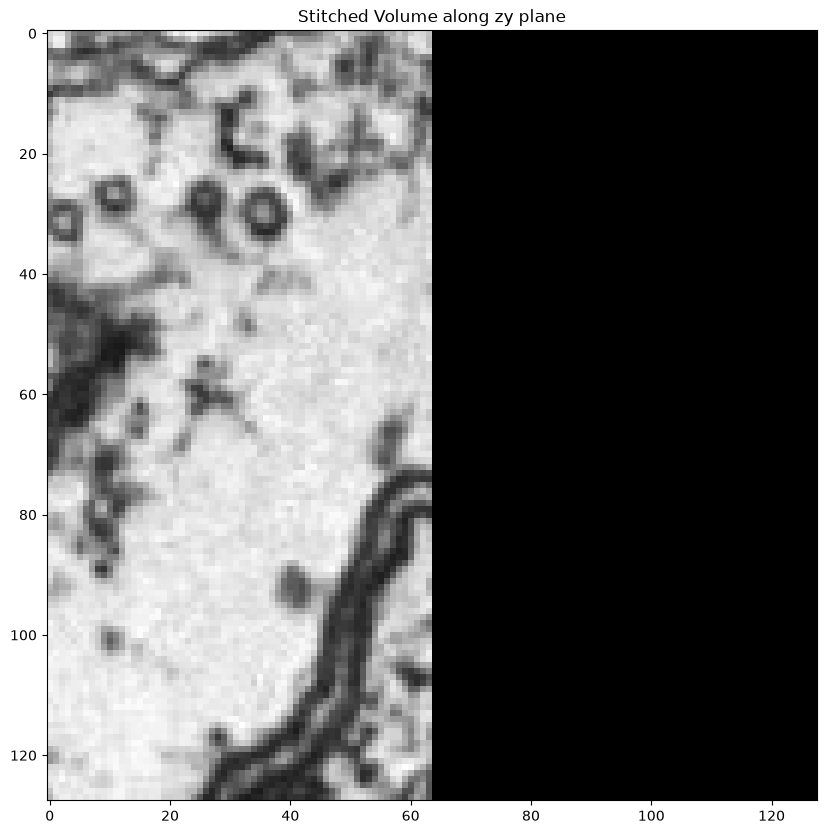

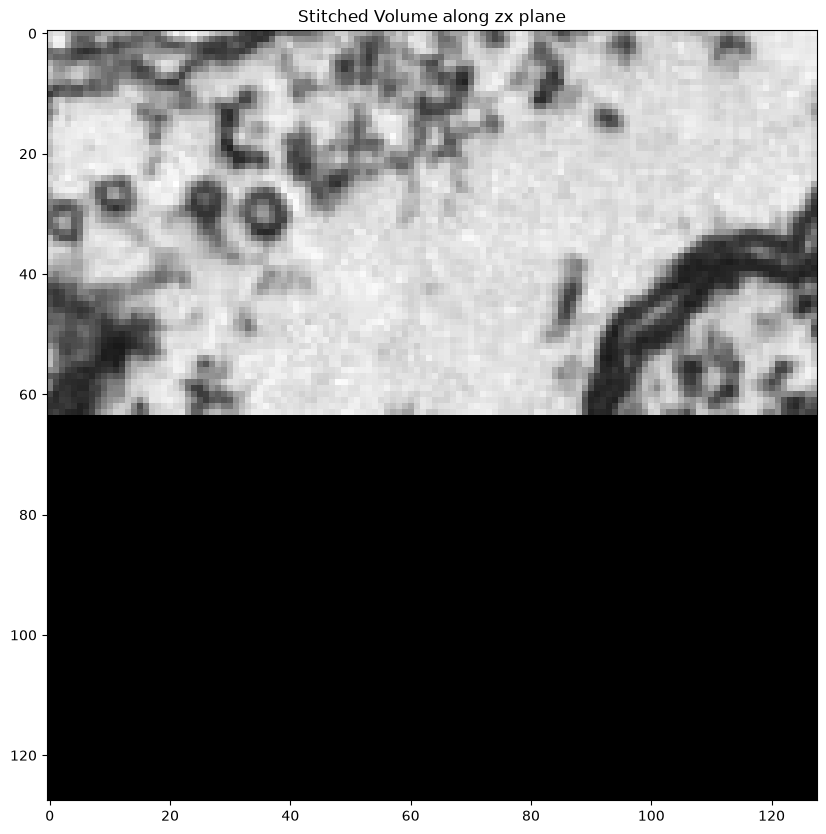

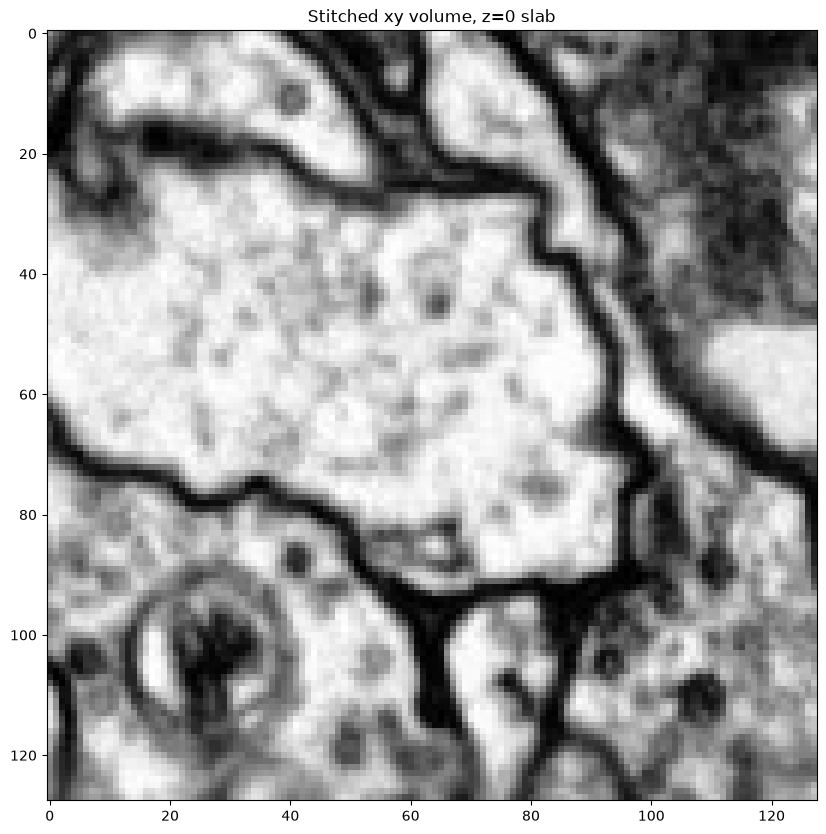

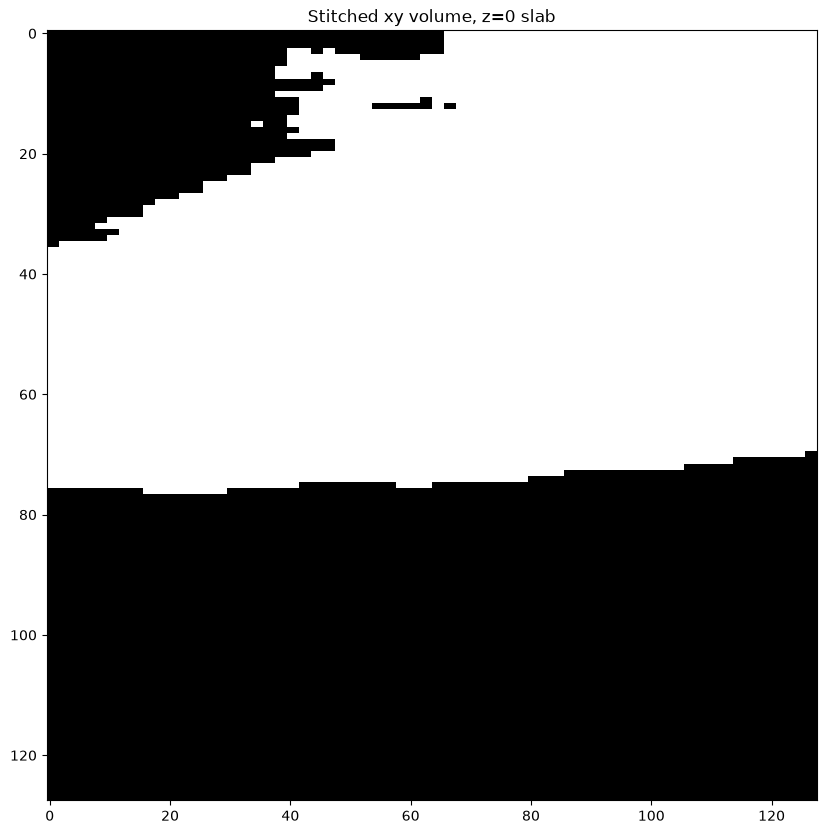

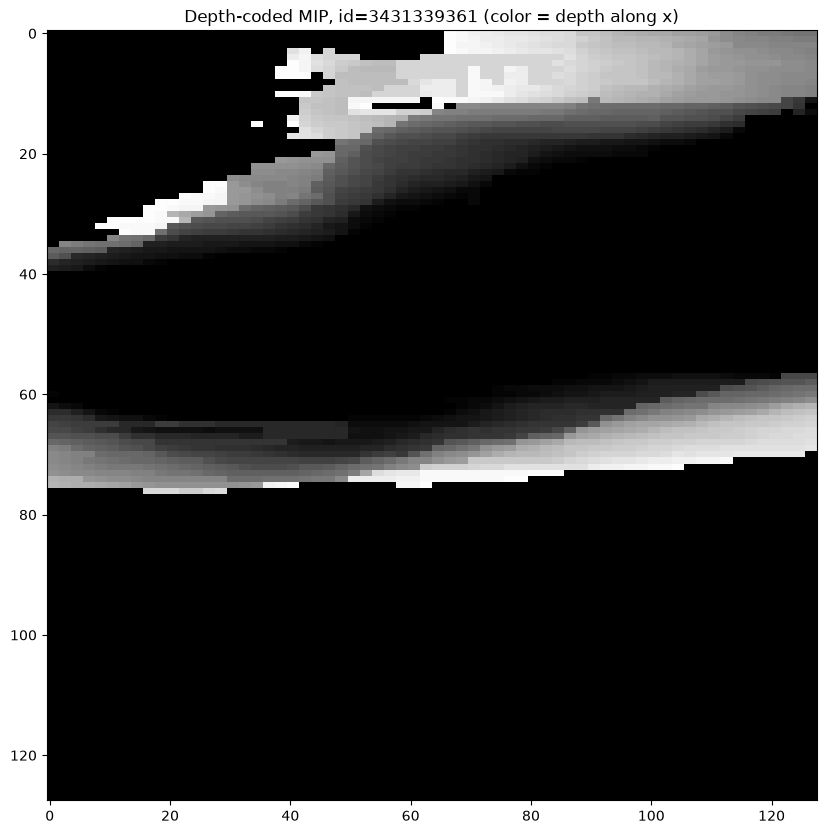

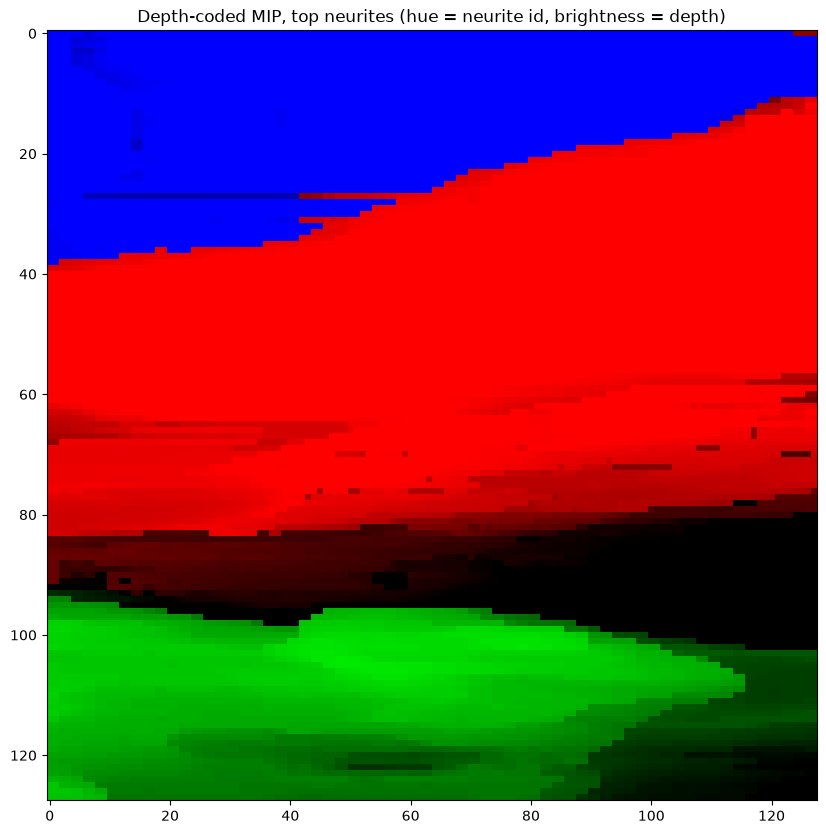

In [9]:
%matplotlib inline
from matplotlib.colors import hsv_to_rgb

# A flat MIP (np.max(mask, axis=...)) collapses depth entirely: every voxel along the
# projection axis contributes the same way, so branches at different depths merge into
# one flat silhouette. Depth-coding fixes this by colouring each surface pixel by *how
# deep* along that axis its nearest voxel sits, so the projection keeps a 3D cue.

def depth_coded_mip(mask_volume, axis, cmap_name='gray'):
    """MIP along `axis`, coloured by the depth (index along `axis`) of the first
    non-background voxel hit — shallow surfaces map to one end of the colormap,
    deep ones to the other, instead of collapsing to flat white/black."""
    depth = mask_volume.shape[axis]
    vol = np.moveaxis(mask_volume, axis, 0)
    present = vol > 0
    has_any = present.any(axis=0)
    first_hit = np.argmax(present, axis=0)  # index of first True along axis
    depth_norm = np.where(has_any, first_hit / max(depth - 1, 1), 0.0)

    cmap = plt.get_cmap(cmap_name)
    rgb = cmap(depth_norm)[..., :3]
    rgb[~has_any] = 0.0  # background stays black
    return rgb

# depth-coded MIP for the single dominant id (still one neurite, but now depth-aware)
top_id_rgb = depth_coded_mip(top_id_mask, axis=2)
plt.figure(figsize=(10, 10))
plt.imshow(top_id_rgb)
plt.title(f'Depth-coded MIP, id={top_id} (color = depth along x)')
plt.show()

# depth-coded MIP across the top neurites at once: hue = which neurite, brightness = depth,
# so distinct branches AND their relative depth both survive the projection into one image
top_ids_no_bg = [i for i in top_ids if i != 0]
axis = 2
vol = np.moveaxis(xy_full, axis, 0)
present = np.isin(vol, top_ids_no_bg)
has_any = present.any(axis=0)
first_hit = np.argmax(present, axis=0)
yx = np.indices(has_any.shape)
label_at_depth = vol[first_hit, yx[0], yx[1]]

id_rank = {rid: i for i, rid in enumerate(top_ids_no_bg)}
hue = np.where(has_any,
               np.vectorize(lambda v: id_rank.get(v, 0))(label_at_depth) / max(len(top_ids_no_bg) - 1, 1),
               0.0)
value = np.where(has_any, 1.0 - first_hit / max(vol.shape[0] - 1, 1), 0.0)  # shallow = bright
saturation = has_any.astype(float)

rgb_multi = hsv_to_rgb(np.stack([hue, saturation, value], axis=-1))

plt.figure(figsize=(10, 10))
plt.imshow(rgb_multi)
plt.title('Depth-coded MIP, top neurites (hue = neurite id, brightness = depth)')
plt.show()

In [10]:
import re
import json
import time
from pathlib import Path
from collections import Counter

# crawl every segment_*.tif block and tally voxel counts per neuron id (id 0 = background, excluded)
blocks_dir = Path('/root/project/data/fafb/blocks')
pat = re.compile(r"segment_z(\d+)_y(\d+)_x(\d+)\.tif$")

seg_paths = [f for f in blocks_dir.iterdir() if pat.match(f.name)]
print(f"scanning {len(seg_paths)} segment blocks for a global voxel-count histogram...")

id_counts = Counter()
t0 = time.time()
for i, f in enumerate(seg_paths):
    vol = tiff.imread(f)
    ids, counts = np.unique(vol, return_counts=True)
    for uid, c in zip(ids.tolist(), counts.tolist()):
        if uid != 0:
            id_counts[uid] += c
    if (i + 1) % 5000 == 0 or (i + 1) == len(seg_paths):
        elapsed = time.time() - t0
        print(f"[{i + 1}/{len(seg_paths)}] unique ids so far: {len(id_counts)} elapsed={elapsed:.0f}s")

top5 = id_counts.most_common(5)
top5_records = [{"id": uid, "voxel_count": c} for uid, c in top5]
print(top5_records)

out_path = Path('/root/project/results/top5_neuron_ids.json')
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, 'w') as fh:
    json.dump(top5_records, fh, indent=2)

top5_records

scanning 262144 segment blocks for a global voxel-count histogram...


[5000/262144] unique ids so far: 130427 elapsed=34s


[10000/262144] unique ids so far: 275702 elapsed=69s


[15000/262144] unique ids so far: 425422 elapsed=103s


[20000/262144] unique ids so far: 572426 elapsed=138s


...

[255000/262144] unique ids so far: 4966384 elapsed=1654s


[260000/262144] unique ids so far: 4966386 elapsed=1681s


[262144/262144] unique ids so far: 4966386 elapsed=1692s


[{'id': 4341159055, 'voxel_count': 410359045}, {'id': 3293809532, 'voxel_count': 290248353}, {'id': 6293835881, 'voxel_count': 194730958}, {'id': 4869512842, 'voxel_count': 135333179}, {'id': 1215218846, 'voxel_count': 104870354}]


[{'id': 4341159055, 'voxel_count': 410359045},
 {'id': 3293809532, 'voxel_count': 290248353},
 {'id': 6293835881, 'voxel_count': 194730958},
 {'id': 4869512842, 'voxel_count': 135333179},
 {'id': 1215218846, 'voxel_count': 104870354}]